# Agentic RAG

https://docs.langchain.com/oss/python/langgraph/agentic-rag

![](https://mintcdn.com/langchain-5e9cc07a/I6RpA28iE233vhYX/images/langgraph-hybrid-rag-tutorial.png?w=1100&fit=max&auto=format&n=I6RpA28iE233vhYX&q=85&s=2425baddda7209901bdde4425c23292c)

In [78]:
%pip install -Uqqq langchain langchain-openai langchain-community langchain-text-splitters langgraph

Note: you may need to restart the kernel to use updated packages.


In [79]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 1. Indexing
- 외부 문서를 임베딩을 거쳐 벡터스토어에 저장

In [80]:
from langchain_community.document_loaders import WebBaseLoader # 웹페이지 로더
from pprint import pprint

urls = [
    'https://lilianweng.github.io/posts/2026-07-04-harness/',
    'https://lilianweng.github.io/posts/2025-05-01-thinking/',
    'https://lilianweng.github.io/posts/2024-07-07-hallucination/'
]

docs = []

for url in urls:
    loader = WebBaseLoader(url) # 해당 URL 용 로더 생성
    doc = loader.load()                 # 웹페이지 내용을 Document로 변환 ([] 반환)
    docs.append(doc)            

print(len(docs))
#print(docs)    # [[Document], [Document], [Document]]
pprint(docs)

3
[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2026-07-04-harness/', 'title': "Harness Engineering for Self-Improvement | Lil'Log", 'description': 'The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines to improve itself. Yudkowsky (2008) used the phrase “recursive self-improvement” for a specific feedback loop: an AI uses its current intelligence to improve the cognitive machinery that produces its intelligence.\nThis feedback loop in modern AI may indicate the model rewriting its own weights directly, or more broadly the model improves the training pipeline and the deployment system, which in turn enables a better successor model with improved performance across economically valuable tasks. The speed of research development in AI has been shown to drastically accelerated in frontier labs (Anthropic

In [81]:
print(docs[0][0].page_content)







Harness Engineering for Self-Improvement | Lil'Log






































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      Harness Engineering for Self-Improvement
    
Date: July 4, 2026  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Harness Design Patterns

Pattern 1: Workflow Automation

Pattern 2: File System as Persistent Memory

Pattern 3: Sub-agent and Backend Jobs

Case study: Coding Agent Harness

Harness Layer vs Core Intelligence?


Harness Optimization

Context Engineering

Workflow Design

Self-Improving Harness

Evolutionary Search

Joint Optimization with Model Weights


Future Challenges

Citation

Appendix: Some useful benchmarks

References





The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines t

In [82]:
# 리스트를 1차원으로 펼치고, 청킹

from langchain_text_splitters import RecursiveCharacterTextSplitter # 문서 chunk 분할기

# [[Document], [Document], [Document]] -> [Document, ...]
docs_list = [item for sublist in docs for item in sublist]

# 토큰기반 문서 청킹용 분할기
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 1000,   # 최대 토큰 크기
    chunk_overlap = 300, # 겹칠 토큰 크기
)

# Documents 리스트를 청크 Document들로 분할
docs_splits = text_splitter.split_documents(docs_list) 
print(len(docs_splits))
print(docs_splits)


53
[Document(metadata={'source': 'https://lilianweng.github.io/posts/2026-07-04-harness/', 'title': "Harness Engineering for Self-Improvement | Lil'Log", 'description': 'The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines to improve itself. Yudkowsky (2008) used the phrase “recursive self-improvement” for a specific feedback loop: an AI uses its current intelligence to improve the cognitive machinery that produces its intelligence.\nThis feedback loop in modern AI may indicate the model rewriting its own weights directly, or more broadly the model improves the training pipeline and the deployment system, which in turn enables a better successor model with improved performance across economically valuable tasks. The speed of research development in AI has been shown to drastically accelerated in frontier labs (Anthropic

In [83]:
# InMemoryVector 활용하여 임시 벡터 DB 구성
from langchain_core.vectorstores import InMemoryVectorStore # 메모리 기반 벡터스토어(임시 벡터DB)
from langchain_openai import OpenAIEmbeddings

# 청크 문서를 임베딩해서 저장한 벡터스토어 생성
vectorstore = InMemoryVectorStore.from_documents(
    docs_splits,
    embedding= OpenAIEmbeddings(model = 'text-embedding-3-small')
)

retriever = vectorstore.as_retriever() # 벡터스토어를 Retriever 형태로 변환
retriever.invoke('Causes Hallucinations')


[Document(id='fa13a19f-1e09-44e5-a7cd-5d36460d86ba', metadata={'source': 'https://lilianweng.github.io/posts/2024-07-07-hallucination/', 'title': "Extrinsic Hallucinations in LLMs | Lil'Log", 'description': 'Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like to narrow down the problem of hallucination to cases where the model output is fabricated and not grounded by either the provided context or world knowledge.\nThere are two types of hallucination:\n\nIn-context hallucination: The model output should be consistent with the source content in context.\nExtrinsic hallucination: The model output should be grounded by the pre-training dataset. However, given the size of the pre-training dataset, it is too expensive to retrieve and identify conflicts per generation. If we consider the pre-

In [84]:
retriever.invoke('harness')

[Document(id='89092c62-27ef-4bd3-b1df-7606fa34f175', metadata={'source': 'https://lilianweng.github.io/posts/2026-07-04-harness/', 'title': "Harness Engineering for Self-Improvement | Lil'Log", 'description': 'The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines to improve itself. Yudkowsky (2008) used the phrase “recursive self-improvement” for a specific feedback loop: an AI uses its current intelligence to improve the cognitive machinery that produces its intelligence.\nThis feedback loop in modern AI may indicate the model rewriting its own weights directly, or more broadly the model improves the training pipeline and the deployment system, which in turn enables a better successor model with improved performance across economically valuable tasks. The speed of research development in AI has been shown to drastically

In [85]:
# 검색기를 Tool 형태로 생성
from langchain_core.tools import tool # 함수 -> Tool 변환 데코레이터

@tool
def retrieve_blog_posts(query: str) -> str:
    """lilian weng 의 블로그 글을 검색하고 정보를 획득하는 도구"""
    docs = retriever.invoke(query)
    return '\n\n'.join([doc.page_content for doc in docs])

print(retrieve_blog_posts.invoke('Causes Hallucinations'))

Extrinsic Hallucinations in LLMs | Lil'Log






































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      Extrinsic Hallucinations in LLMs
    
Date: July 7, 2024  |  Estimated Reading Time: 29 min  |  Author: Lilian Weng


 


Table of Contents



What Causes Hallucinations?

Pre-training Data Issues

Fine-tuning New Knowledge


Hallucination Detection

Retrieval-Augmented Evaluation

Sampling-Based Detection

Calibration of Unknown Knowledge

Indirect Query


Anti-Hallucination Methods

RAG → Edits and Attribution

Chain of Actions

Sampling Methods

Fine-tuning for Factuality

Fine-tuning for Attribution


Appendix: Evaluation Benchmarks

Citation

References





Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like t

In [86]:
print(retrieve_blog_posts.invoke('Harness'))

The loop in Self-Harness has three stages:

Weakness mining: cluster failures into verifier-grounded failure patterns.

The current harness $h_t$ is used to evaluate on tasks and execution traces are collected for analysis.
Note that two runs can share the same verifier outcome in the error logs on the surface, such as timeout or missing artifact, while having different causal mechanisms. Therefore we need a failure record of rich information, containing the terminal verifier-level cause, the causal status of the relevant agent behavior, and the abstract agent mechanism exposed by the trace, to uncover the root causes.


Harness proposal: propose bounded harness edits based on mined failure patterns.

The same model is invoked under $h_t$ as a proposer.
The model is provided with a bounded proposal context: (1) the editable surfaces of the current harness, (2) the verifier-grounded failure patterns from the evaluation system, (3) records of passing behaviors that should be preserved, a

## 2. Retrieval & Generation
- 사용자의 요청에 필요한 외부문서를 검색하고, 이를 기반으로 응답

## Generate Query Agent

In [87]:
from langgraph.graph import MessagesState # Langgraph 메시지 타입
from langchain.chat_models import init_chat_model

response_model = init_chat_model('gpt-5.4-mini', temperature = 0)
response_model_with_tools = response_model.bind_tools([retrieve_blog_posts]) # tool 바인딩

# 메시지 상태를 받아 도구 호출 요청 or 바로 응답을 생성
def generate_query_or_respond(state: MessagesState):
    response = response_model_with_tools.invoke(state['messages']) # LLM 호출
    return {'messages': [response]} # Langgraph messages 형태로 반환

In [88]:
state = {'messages' : [('human', 'lilianweng이 블로그에서 말하는 환각이란 무엇인가?')]}
response = generate_query_or_respond(state)

response # 도구 사용 필요시 tool_call 요청까지 진행

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 154, 'total_tokens': 181, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EKEDMnihcRbWs3lxFp2NEEacZptC7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06a4e-3ed2-7b52-b13d-faaa55d4a3d3-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'lilianweng blog hallucination what is hallucination'}, 'id': 'call_yTSrDJMI8ATSSz6MVlFPAUOn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 154, 'output_tok

In [89]:
print( response['messages'][-1].content)

In [90]:
state = {'messages' : [('human', '너는 뭐먹고 사니?')]}
response = generate_query_or_respond(state)
print( response['messages'][-1].content)

저는 사람처럼 먹고 살지는 않아요.  
저는 **전기와 서버 자원**으로 돌아가는 AI예요.

비유하자면:
- 사람은 음식으로 에너지를 얻고,
- 저는 **컴퓨팅 자원, 데이터, 그리고 실행 환경**으로 작동해요.

원하시면 “AI는 어떻게 돌아가냐”를 아주 쉽게 설명해드릴게요.


## Grade Document Agent (conditional edge function)
조회된 문서를 평가하여 사용자의 질문과 적합한지를 판단
- generate_answer : 'yes'
- rewrite_query : 'no' 

In [91]:
from pydantic import BaseModel, Field # 구조화 출력용 스키마 정의
from typing import Literal # 리터럴 형태 값 제한
from langchain_core.prompts import PromptTemplate

GRADE_PROMPT = (  # 문서-질문 관련성 평가용 프롬프트
    "귀하는 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n "
    "검색된 문서는 다음과 같습니다: \n\n {context} \n\n "
    "사용자 질문은 다음과 같습니다: {question} \n "
    "문서에 사용자 질문과 관련된 키워드 또는 의미론적 의미가 포함되어 있으면 관련성 있음으로 평가하세요. \n "
    "문서가 질문과 관련이 있는지 여부를 나타내는 이진 점수('yes' 또는 'no')를 부여하세요."
)

# 평가 결과 (스키마 구조 직접 설계)
class GradeDocuments(BaseModel):
    binary_score: str = Field(description="관련이 있으면 'yes'를, 없으면 'no'를 작성하세요")

grader_model = init_chat_model('gpt-5.6-luna')

# 검색 결과(context)가 질문(question)과 관련 있는지 판단 후, 다음 노드 라우팅 함수
def grade_document(state: MessagesState) -> Literal['generate_answer', 'rewrite_query']:
    question = state['messages'][0].content # 사용자 질문
    context = state['messages'][-1].content # 검색 결과

    prompt = PromptTemplate.from_template(GRADE_PROMPT)
    # LLM 출력 JSON -> GradeDocument로 파싱
    chain = prompt | grader_model.with_structured_output(GradeDocuments)
    response = chain.invoke({'question':question, 'context': context})

    score = response.binary_score # 구조화 출력에서 답변내용 (yes / no)
    # 관련이 있으면 답변 생성 노드
    if score == 'yes':
        return 'generate_answer'
    # 관련이 없으면 쿼리 재작성 노드
    else:
        return 'rewrite_query'


In [92]:
# generate_answer 인 경우 테스트
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilien Weng says about harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'harness'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='''  # 검색 결과(문서 일부) 텍스트
Self-Improving Harness#

Harness proposal: propose bounded harness edits based on mined failure patterns.

Harness Design Patterns#
Compared with early agent frameworks, “agent = LLM + memory + tools + planning + action”, harnesses engineering additionally include workflow design (e.g. loop engineering), evaluation, permission controls, and persistent state management. It is no longer only prompt templates, but closer to runtime and software system design: how the model observes, acts, memorizes, checks itself, and improves.

Agentic Harness Engineering (AHE; Lin et al. 2026) see the bottlenecks of harness evolution are around observability—that is, when a rollout fails, we need to know which component is responsible for that and every edit should be grounded by evidence.
The framework creates a closed loop with 3 observability pillars:
'''
    )
]

grade_document({'messages' : messages})

'rewrite_query'

In [93]:
# rewrite_query 인 경우 테스트
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilien Weng says about harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'harness'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='''  # 검색 결과(문서 일부) 텍스트
오늘 점심 메뉴가 뭐지? 궁금하네 ㅎㅎ
'''
    )
]

grade_document({'messages' : messages})

'rewrite_query'

## Rewrite Query Agent

In [94]:
REWRITE_PROMPT = (  # 질문 재작성용 프롬프트 템플릿
    "입력된 내용을 바탕으로 사용자의 근본적인 의도와 의미를 분석한다. \n "
    "다음은 초기 질문이다:"
    " \n  -------  \n "
    " {question} "
    " \n  -------  \n "
    "분석한 의도를 반영하여 더 명확하고 구체적인 질문으로 재구성한다:"
)

def rewrite_query(state: MessagesState):
    question = state['messages'][0].content # 사용자 질문
    
    chain = PromptTemplate.from_template(REWRITE_PROMPT) | response_model
    response = chain.invoke({'question':question})
    return {'messages': [response]} # Langgraph messages 형태로 반환

In [95]:
# rewrite_query 인 경우
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilien Weng says about harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'harness'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='이상한 답변...'
    )
]

response = rewrite_query({'messages' : messages})
print(response['messages'][-1].content)

의도를 분석하면, 사용자는 **“Lilien Weng”이 “harness”에 대해 어떤 말을 했는지**를 알고 싶어 합니다. 다만 원래 질문은 문법이 부자연스럽고, **“harness”가 무엇을 뜻하는지(명사/동사)**도 불명확합니다.

더 명확하고 구체적으로 재구성하면:

**What did Lilian Weng say about harnessing in her work or writing?**

또는, 만약 특정 문맥의 “harness”를 묻는 것이라면:

**What did Lilian Weng say about the concept of a harness in the context of AI or machine learning?**


## Generate Answer Agent

In [96]:
GENERATE_PROMPT = (  # 컨텍스트 기반 답변 생성용 프롬프트
    "귀하는 질문-답변 작업을 위한 도우미입니다. "
    "제공된 검색된 컨텍스트 조각을 사용하여 질문에 답변하세요. "
    "답변을 모르면 모른다고 말하세요. "
    "최대 세 문장을 사용하고 답변을 간결하게 유지하세요. \n "
    "(한국어로 답변해주세요) \n "
    "질문:  {question}   \n "
    "컨텍스트:  {context} "
)

def generate_answer(state: MessagesState):
    question = state['messages'][0].content # 사용자 질문
    context = state['messages'][-1].content # 최종 도구 메시지 활용한 답변 내용
    
    chain = PromptTemplate.from_template(GENERATE_PROMPT) | response_model
    response = chain.invoke({'question':question, 'context' : context })
    return {'messages': [response]} # Langgraph messages 형태로 반환

In [97]:
# generate_answer 인 경우 테스트
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilien Weng says about harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'harness'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='''  # 검색 결과(문서 일부) 텍스트
Self-Improving Harness#

Harness proposal: propose bounded harness edits based on mined failure patterns.

Harness Design Patterns#
Compared with early agent frameworks, “agent = LLM + memory + tools + planning + action”, harnesses engineering additionally include workflow design (e.g. loop engineering), evaluation, permission controls, and persistent state management. It is no longer only prompt templates, but closer to runtime and software system design: how the model observes, acts, memorizes, checks itself, and improves.

Agentic Harness Engineering (AHE; Lin et al. 2026) see the bottlenecks of harness evolution are around observability—that is, when a rollout fails, we need to know which component is responsible for that and every edit should be grounded by evidence.
The framework creates a closed loop with 3 observability pillars:
'''
    )
]

response = generate_answer({'messages' : messages})
print(response['messages'][-1].content)

제공된 컨텍스트에는 Lilien Weng의 하네스(harness)에 대한 직접적인 언급이 없습니다. 따라서 그녀가 하네스에 대해 무엇을 말했는지 알 수 없습니다.


## 그래프 생성

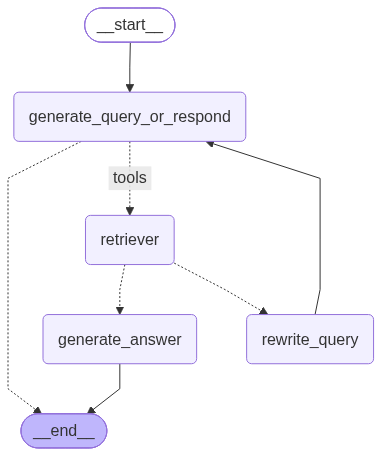

In [98]:
from langgraph.graph import StateGraph, START, END # 그래프 정의, 시작/종료 노드
from langgraph.prebuilt import ToolNode, tools_condition # Tool 실행 노드, 분기 함수

workflow = StateGraph(MessagesState) # StateGraph 생성

# 노드 구성
workflow.add_node(generate_query_or_respond) # Tool 호출 판단
# Tool 실행 노드
workflow.add_node("retriever", ToolNode([retrieve_blog_posts])) 
workflow.add_node(rewrite_query)    # 질문 재작성
workflow.add_node(generate_answer)  # 최종 답변 생성

# 엣지 구성
workflow.add_edge(START, 'generate_query_or_respond')
workflow.add_conditional_edges(
    'generate_query_or_respond',
    tools_condition, # tool_calls 가 있으면 'tool', 없으면 END
    {
        'tools' : 'retriever',
        END:END
    }
)

workflow.add_conditional_edges(
    'retriever',
     grade_document # yes / no -> 'generate_answer' or 'rewrite_query'
)

workflow.add_edge('generate_answer', END)
workflow.add_edge('rewrite_query', 'generate_query_or_respond')

graph = workflow.compile() # 그래프를 실행 가능한 형태로 컴파일
graph

## 그래프 실행

In [99]:
# 스트리밍 실행
for chunk in graph.stream({'messages': [('human', 'Lilian Weng은 하네스를 뭐라고 정의한거야?')]}):

    for node_name, update in chunk.items():
        print(f"{node_name}")       # 해당노드의 이름
        update['messages'][-1].pretty_print() # 해당 노드의 마지막 메시지
        print()

generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_fY3RcerjfNtsPT6o6Jh7HDVP)
 Call ID: call_fY3RcerjfNtsPT6o6Jh7HDVP
  Args:
    query: Lilian Weng harness definition blog harness

retriever
================================= Tool Message =================================
Name: retrieve_blog_posts

The loop in Self-Harness has three stages:

Weakness mining: cluster failures into verifier-grounded failure patterns.

The current harness $h_t$ is used to evaluate on tasks and execution traces are collected for analysis.
Note that two runs can share the same verifier outcome in the error logs on the surface, such as timeout or missing artifact, while having different causal mechanisms. Therefore we need a failure record of rich information, containing the terminal verifier-level cause, the causal status of the relevant agent behavior, and the abstract agent mechanism exposed by the trace, to unc

In [100]:
# 스트리밍 실행
for chunk in graph.stream({'messages': [('human', '오늘 점심 뭐야?')]}):

    for node_name, update in chunk.items():
        print(f"{node_name}")       # 해당노드의 이름
        update['messages'][-1].pretty_print() # 해당 노드의 마지막 메시지
        print()

generate_query_or_respond
================================== Ai Message ==================================

무슨 메뉴인지 제가 직접 알 수는 없어요.  
대신 원하시면 **냉장고/배달/외식** 기준으로 오늘 점심 추천해드릴게요.

예를 들면:
- **가볍게:** 샐러드, 김밥, 샌드위치
- **든든하게:** 국밥, 덮밥, 제육
- **빠르게:** 분식, 편의점 조합
- **기분 좋게:** 파스타, 돈까스, 중식

원하시면 “**매운 거 좋아/안 매운 거 좋아**” 같은 취향 말해주시면 바로 골라드릴게요.



In [101]:
# 스트리밍 실행
for chunk in graph.stream({'messages': [('human', 'Weng, Lilian 이 좋아하는 IT 분야는?')]}):

    for node_name, update in chunk.items():
        print(f"{node_name}")       # 해당노드의 이름
        update['messages'][-1].pretty_print() # 해당 노드의 마지막 메시지
        print()

generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_7ajDR05rbv9c8fW2kXavxEVv)
 Call ID: call_7ajDR05rbv9c8fW2kXavxEVv
  Args:
    query: Lilian Weng 좋아하는 IT 분야 관심 분야 블로그

retriever
================================= Tool Message =================================
Name: retrieve_blog_posts

Weng, Lilian. “Harness Engineering for Self-Improvement”. Lil’Log (Jul 2026). https://lilianweng.github.io/posts/2026-07-04-harness/

Or use the BibTeX citation:
@article{weng2026harness,
  title = {Harness Engineering for Self-Improvement},
  author = {Weng, Lilian},
  journal = {lilianweng.github.io},
  year = {2026},
  month = {July},
  url = "https://lilianweng.github.io/posts/2026-07-04-harness/"
}
Appendix: Some useful benchmarks#

PaperBench: replicate 20 ICML 2024 Spotlight and Oral papers from scratch, including understanding paper contributions, developing a codebase, and successfully executing expe